In [1]:
# Setup and imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# Repo-Root vor dem site-packages-Paket in den sys.path einfügen, damit
# Änderungen am lokalen mdxplain-Code ohne Neuinstallation wirksam werden
PROJECT_ROOT = Path.cwd().resolve().parents[2]  # mdxplain/spec/tests -> repo root
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

from mdxplain import PipelineManager
from mdxplain import SpecManager

📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_d66ae6bc773b4c8a8e0cdacd7d5728d2_20260908_132523/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...
  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...
  ✅ Cache created: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_d66ae6bc773b4c8a8e0cdacd7d5728d2_20260908_132523/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  📊 Size: 89.0 MB

Loaded 1 systems with 1 total trajectories:
  2RJY: 1 trajectories
Loading 117.5 MB coordinate data...
Generated 1953 residue pairs for 64 residues
Created feature selector: 'contacts_only'
Added to selector 'contacts_only': contacts -> 'all' (use_reduced=False, common_denominator=True, traj_selection=all, require_all_partners=False)
Applied feature selector 'contacts_only' with reference trajectory 0 successfully
Created feature selector: 'contacts_wit

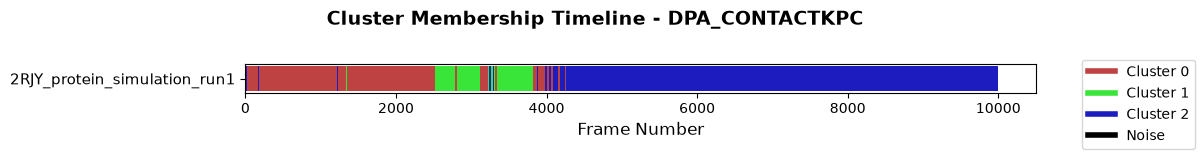

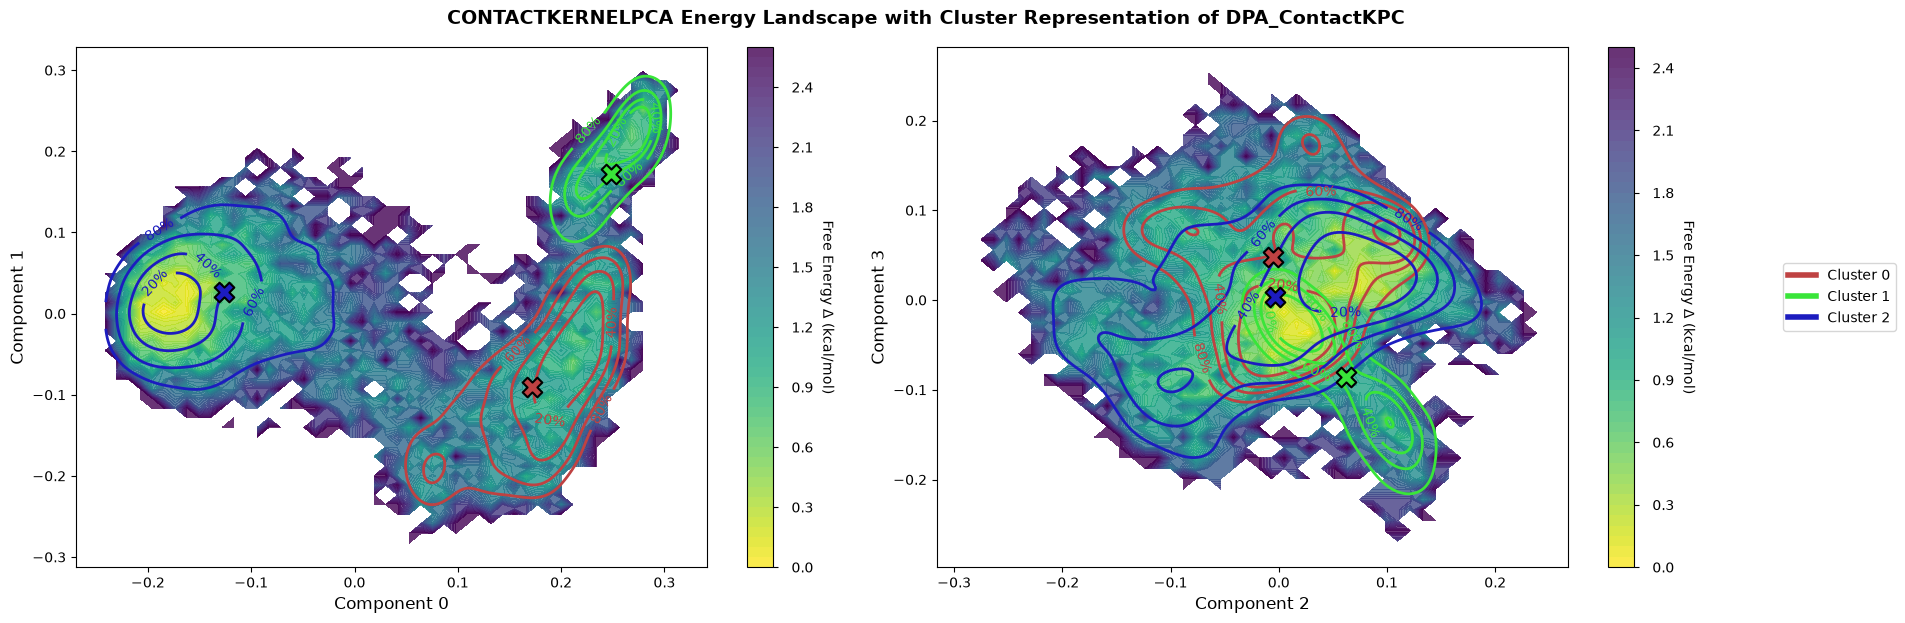

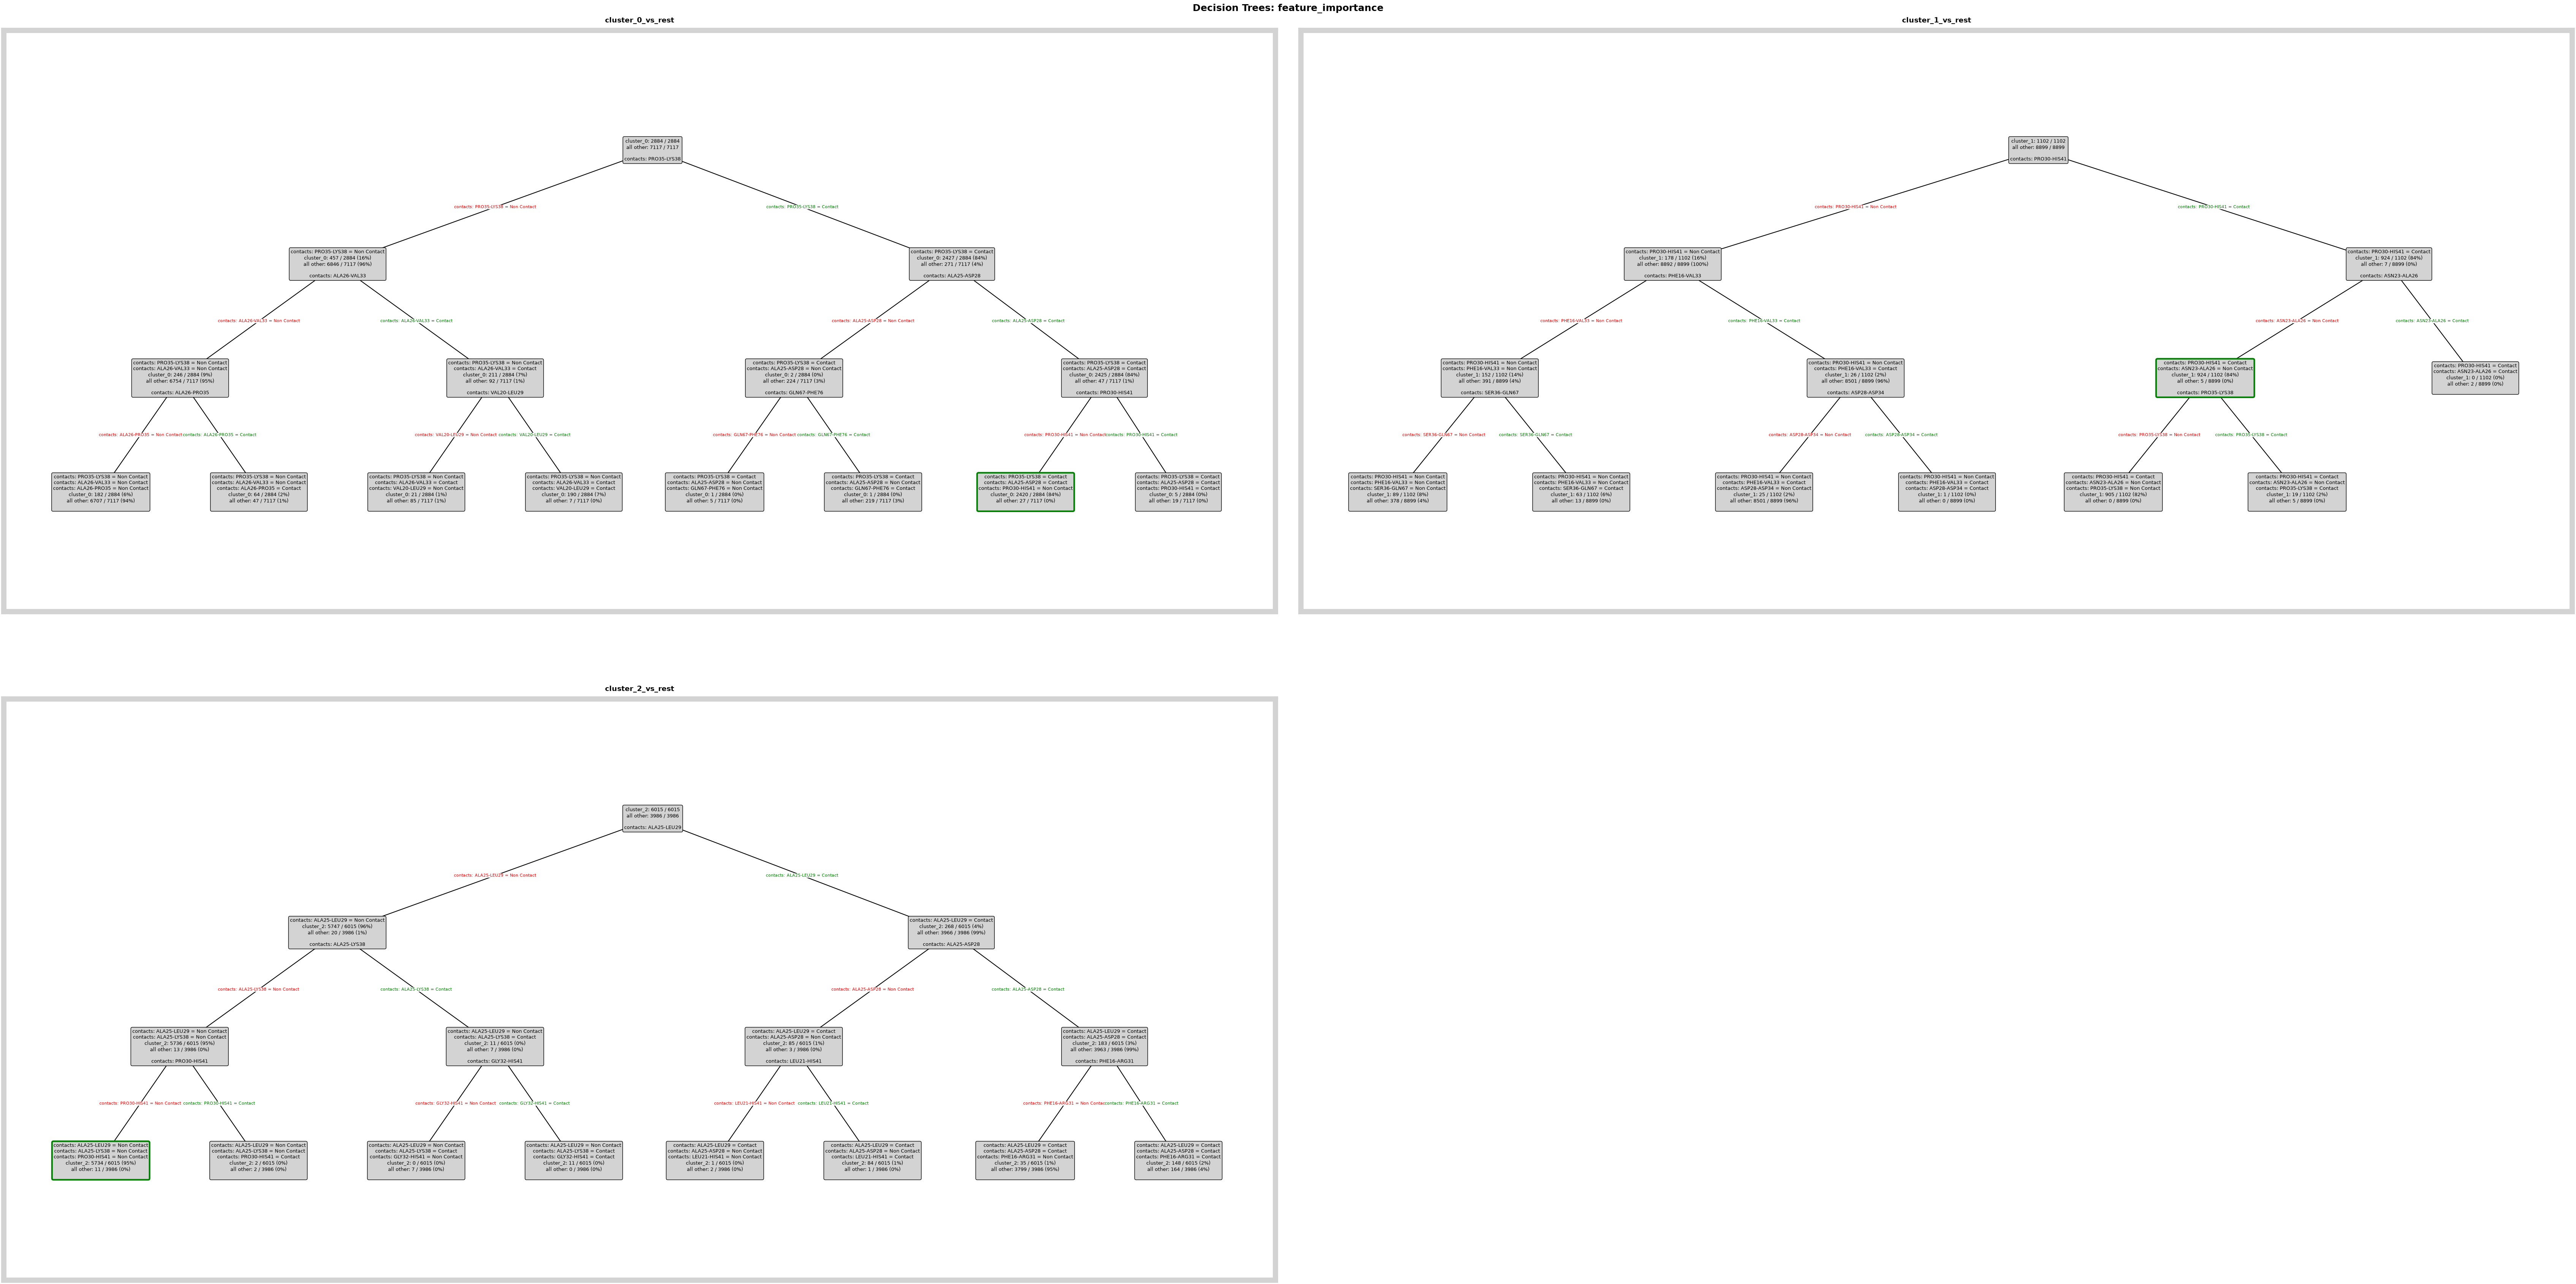

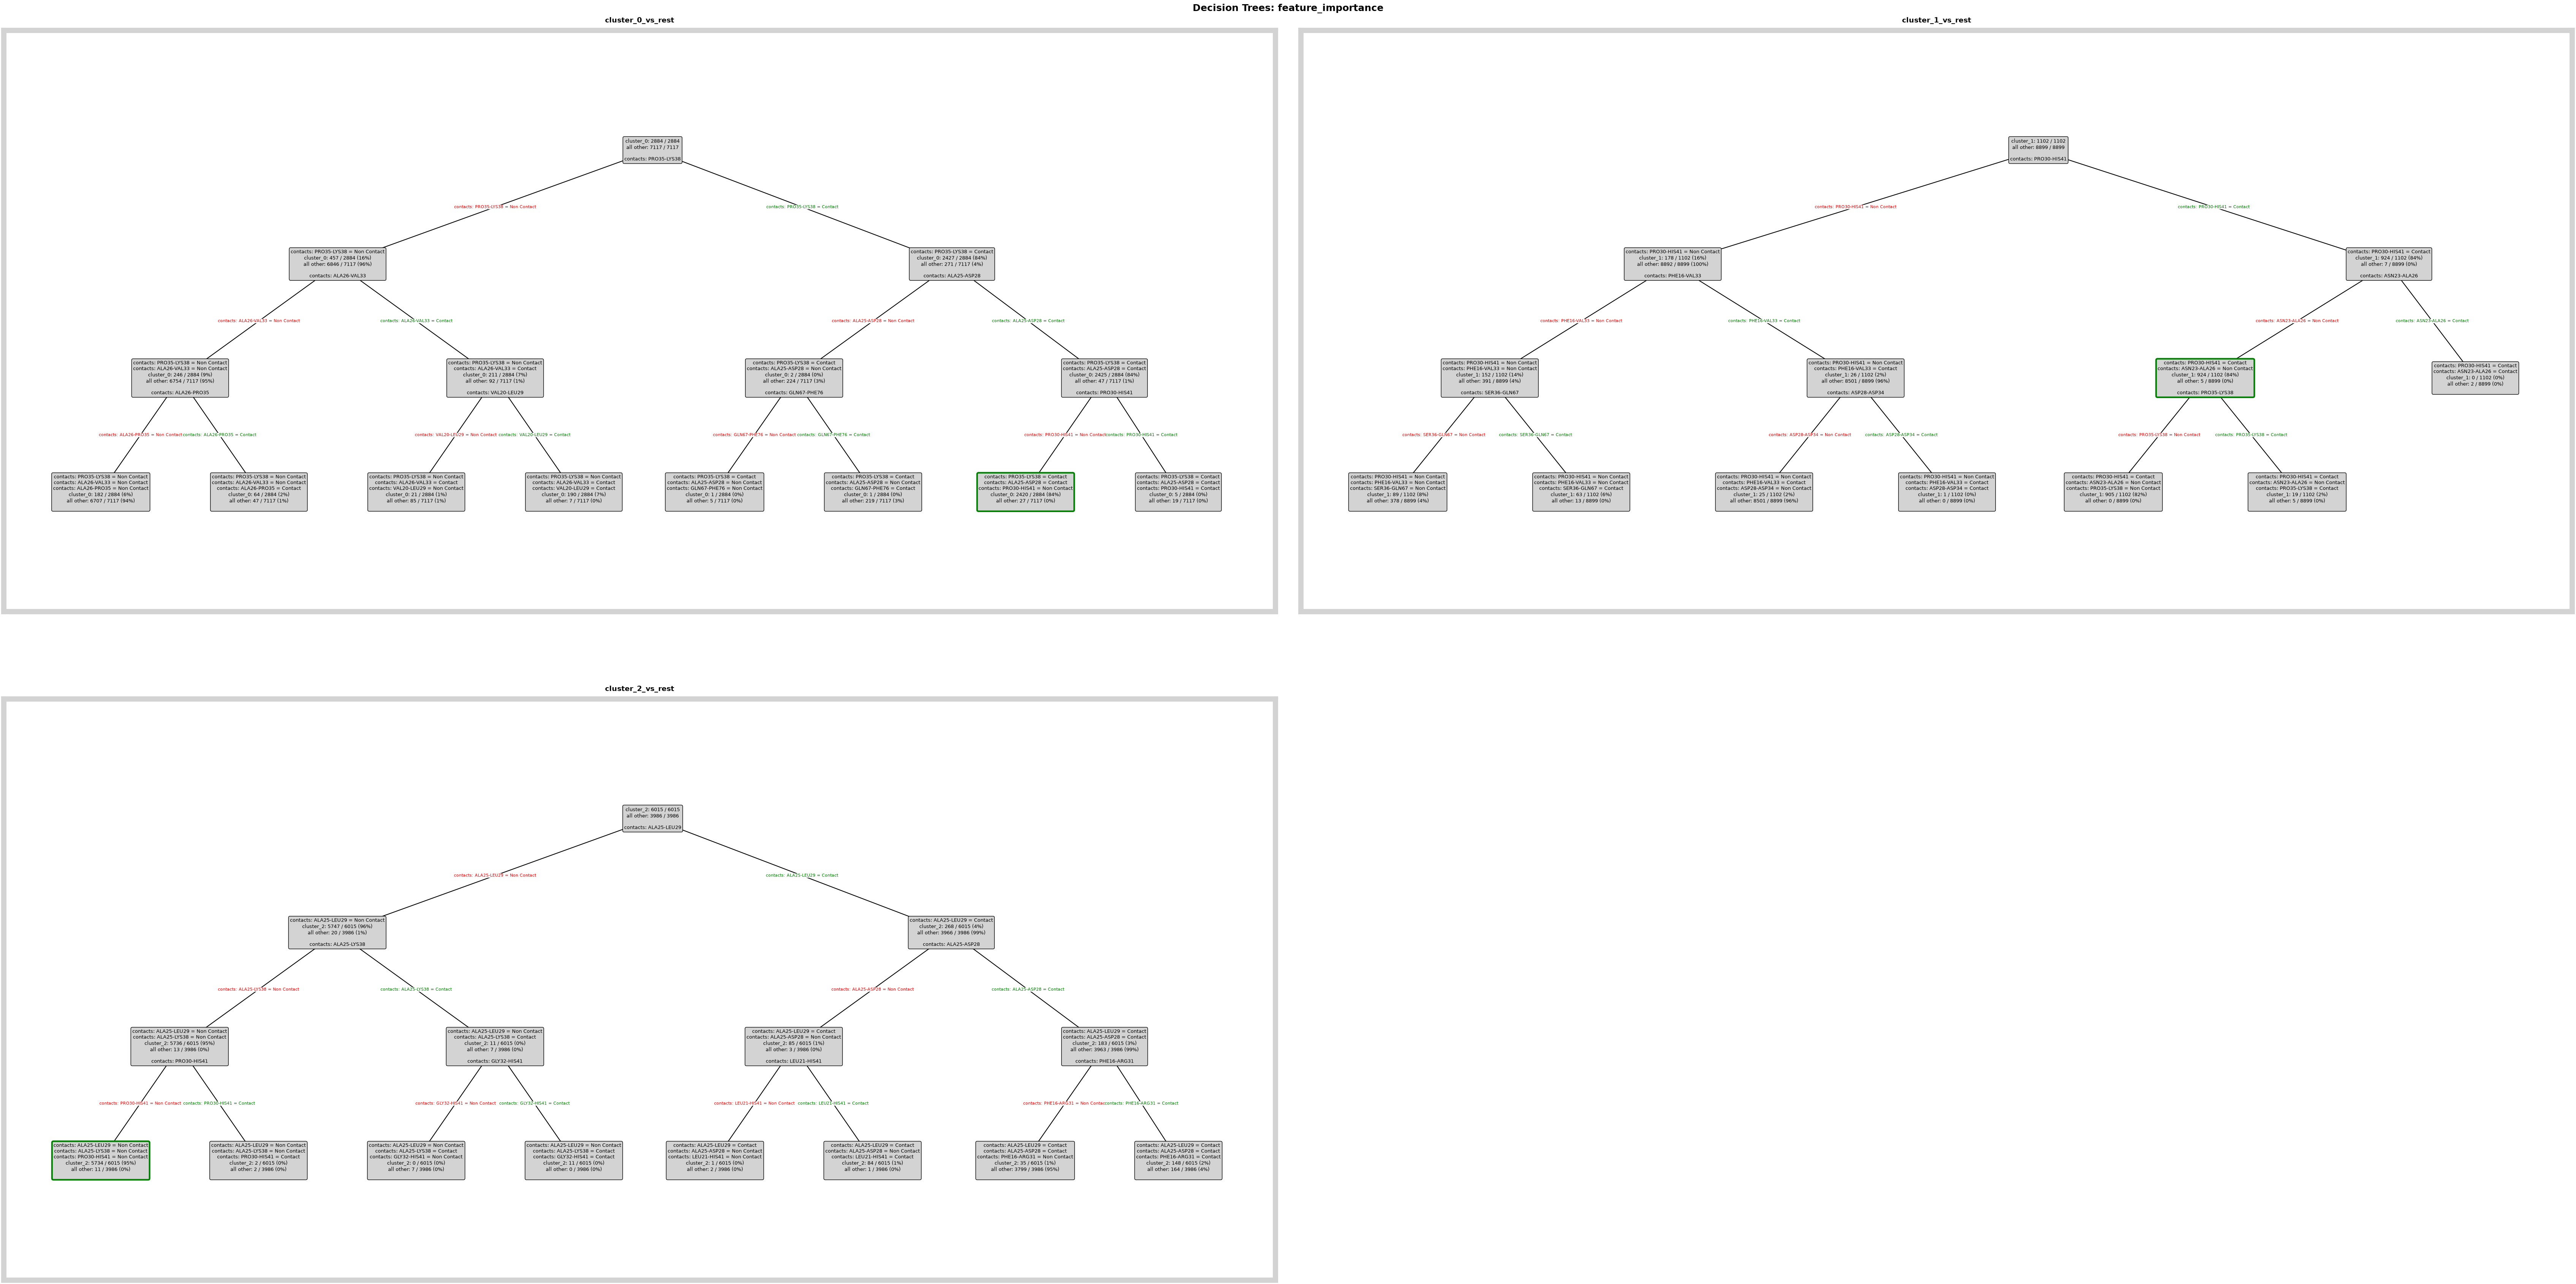

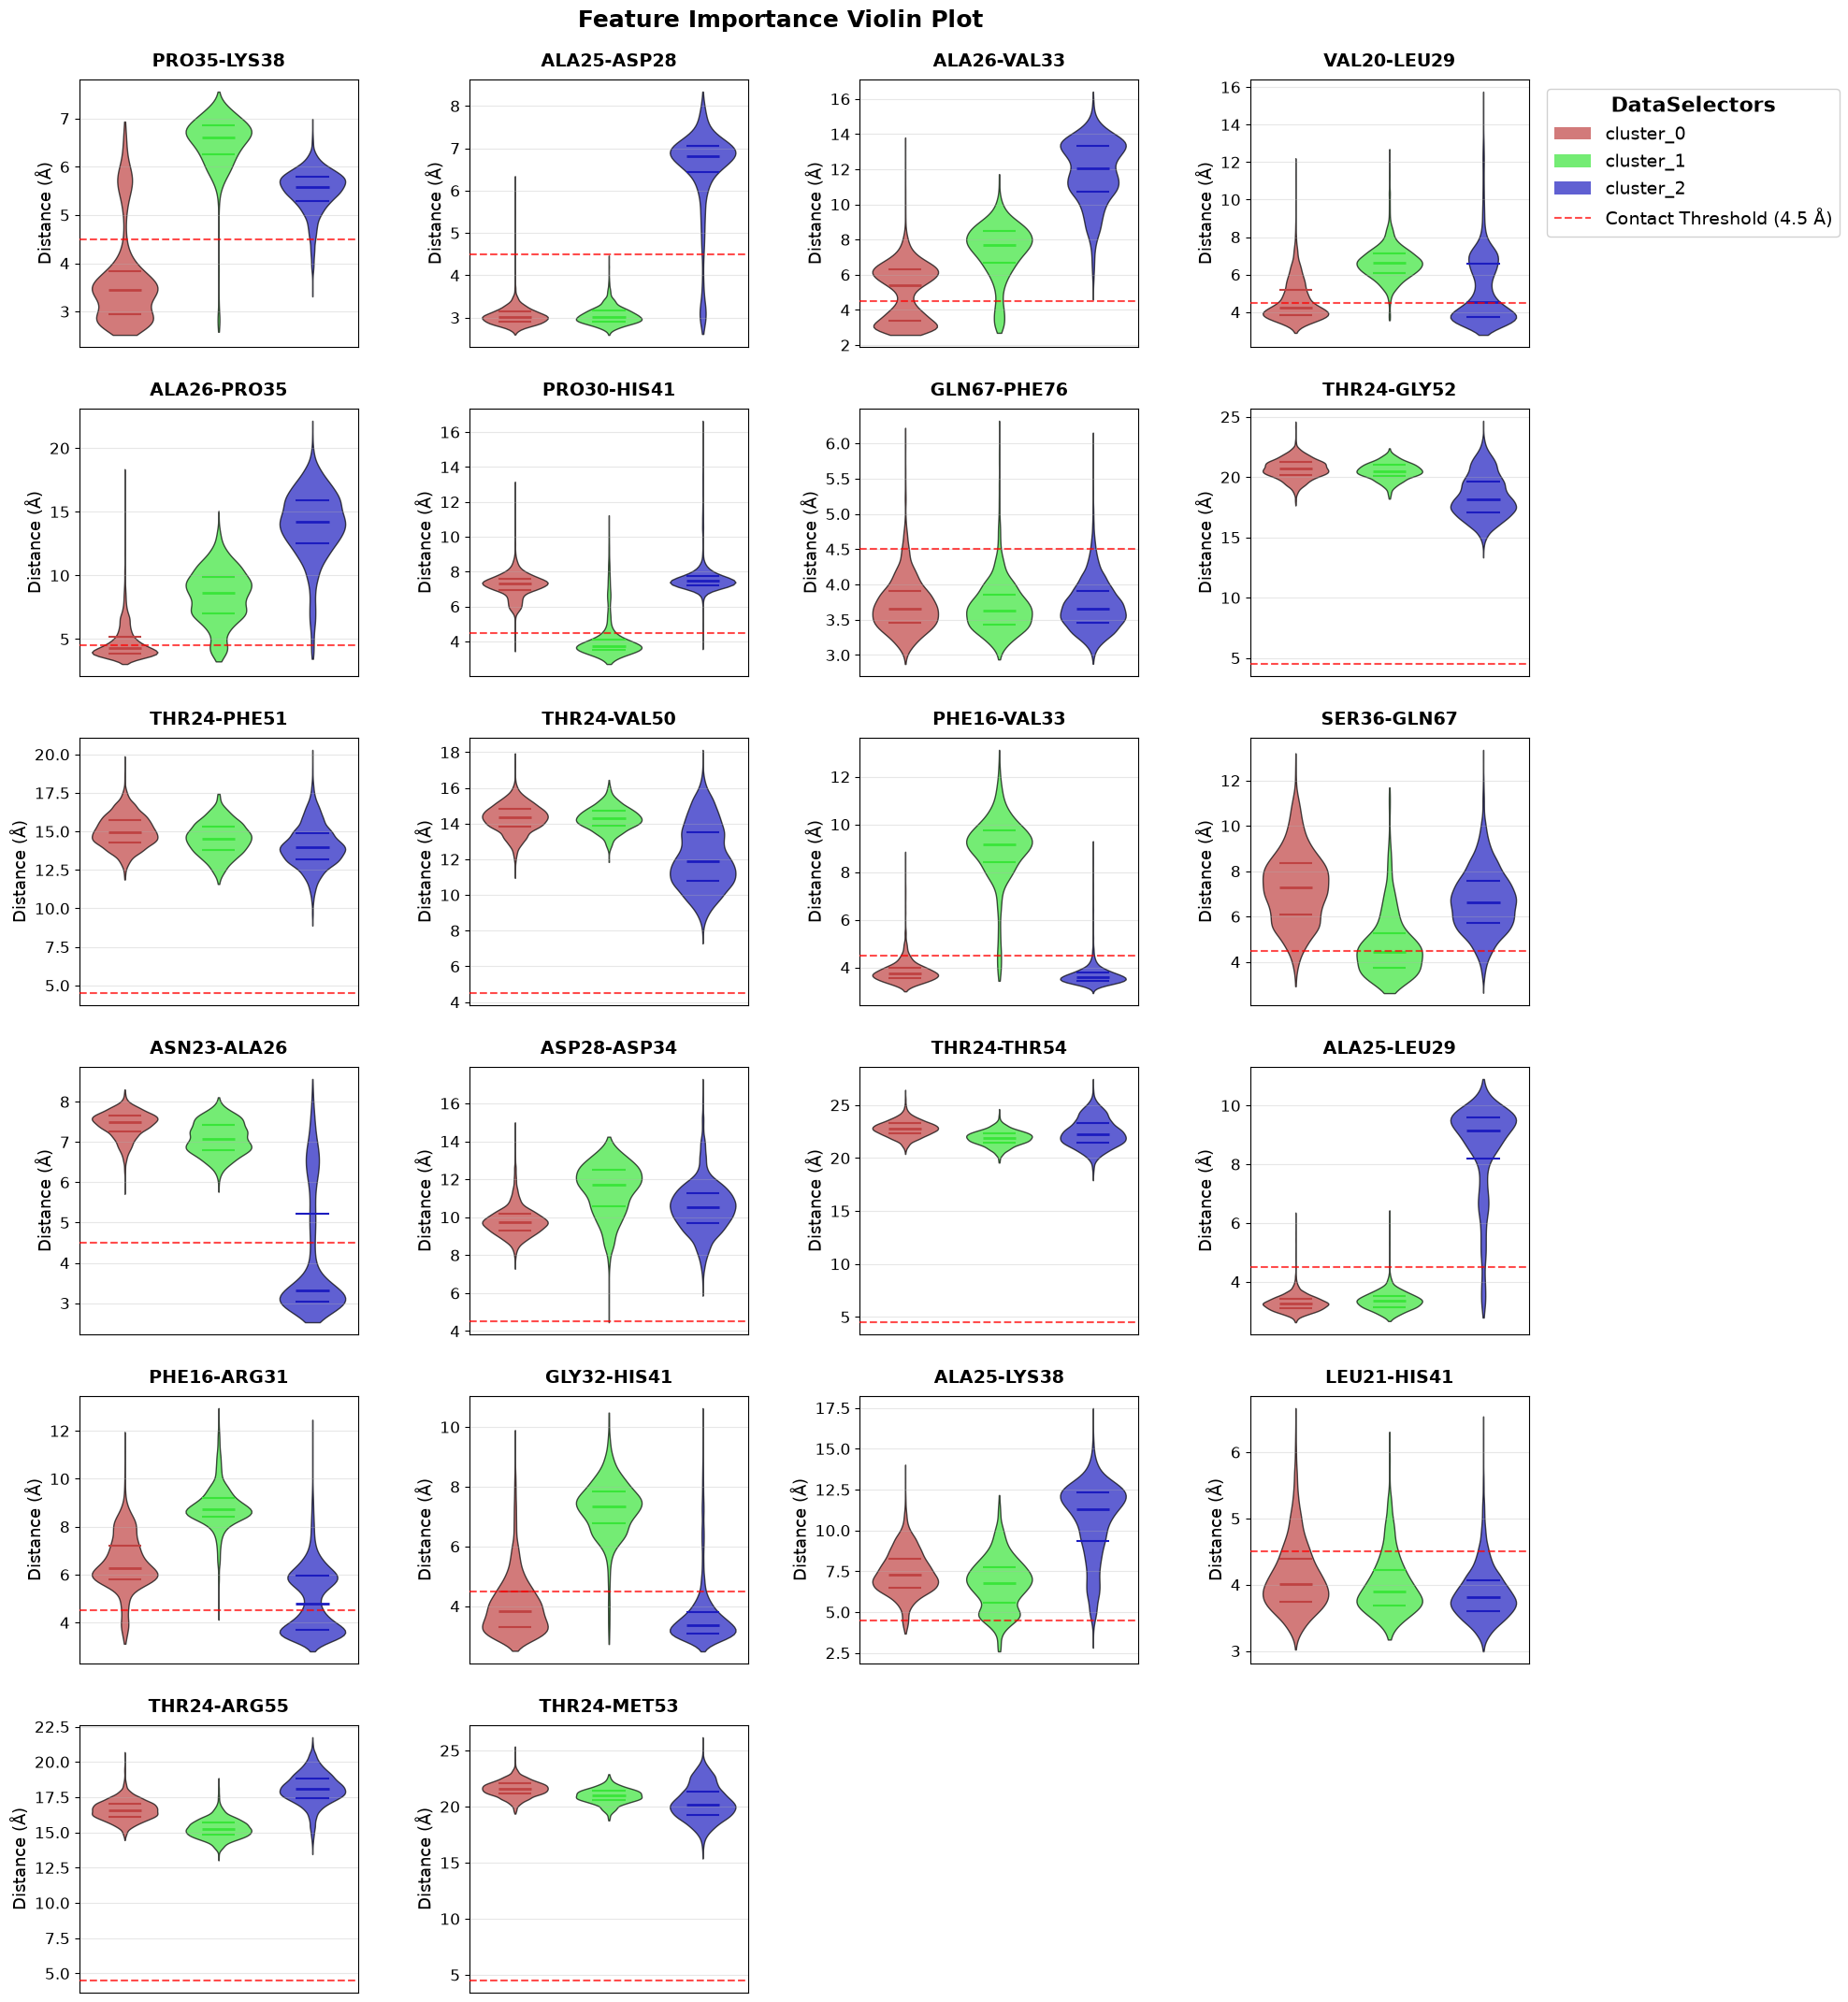

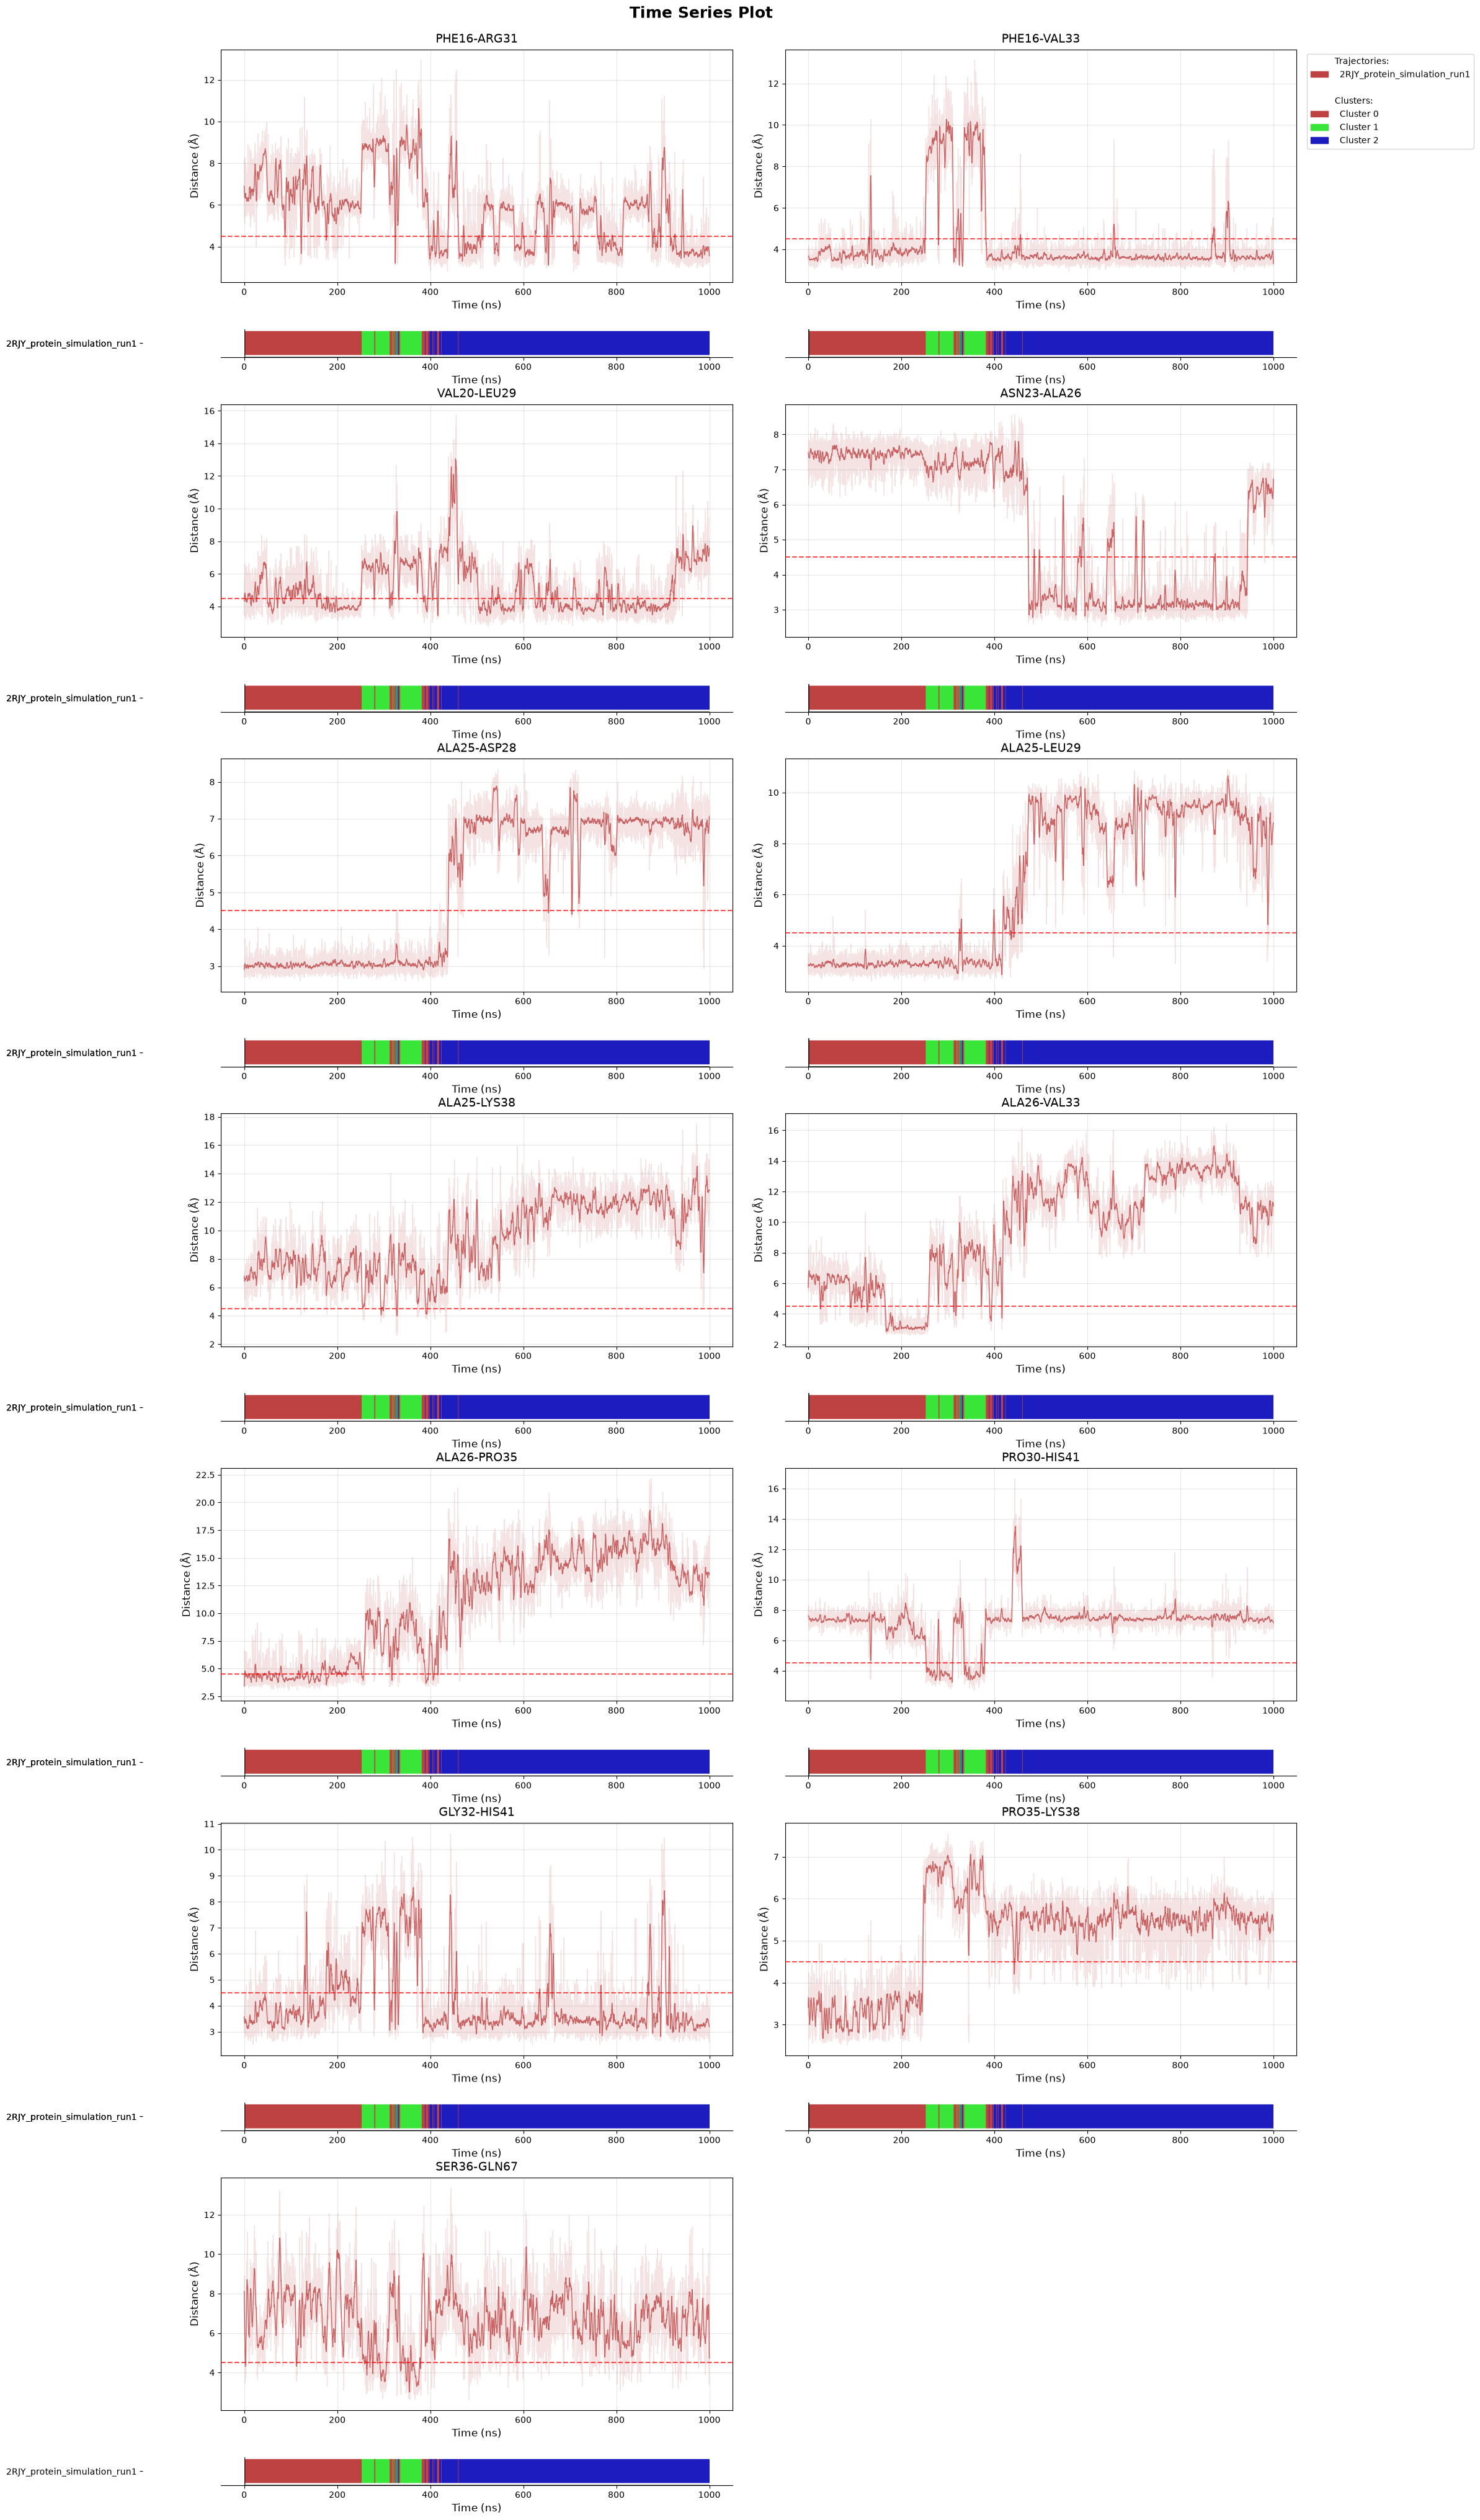

In [2]:
pipeline = PipelineManager(use_memmap=True, chunk_size=1000, show_progress=False)

pipeline.trajectory.load_trajectories("../../../data/2RJY/")
pipeline.trajectory.add_labels(
        traj_selection="all"
    )
pipeline.feature.add.distances()
pipeline.feature.add.contacts(cutoff=4.5)
pipeline.feature.add.torsions()
pipeline.feature_selector.create("contacts_only")
pipeline.feature_selector.add.contacts("contacts_only", "all")
pipeline.feature_selector.select("contacts_only")
pipeline.feature_selector.create("contacts_with_frequency_reduction")
pipeline.feature_selector.add.contacts.with_frequency_reduction("contacts_with_frequency_reduction", "all", threshold_min=0.5)
pipeline.decomposition.add.contact_kernel_pca(
    n_components=4,
    selection_name="contacts_only", 
    decomposition_name="ContactKernelPCA",
)
pipeline.clustering.add.dpa(
    "ContactKernelPCA", 
    Z=2.5,
    cluster_name="DPA_ContactKPC",
)
fig = pipeline.plots.clustering.membership(
    clustering_name="DPA_ContactKPC",
)
fig = pipeline.plots.landscape(
    decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_ContactKPC",
)
pipeline.data_selector.create_from_clusters(
    group_name="cluster",
    clustering_name="DPA_ContactKPC"
)

# Create one-vs-all comparison
pipeline.comparison.create_comparison(
    name="cluster_comparison",
    mode="one_vs_rest",
    feature_selector="contacts_only",
    data_selector_groups="cluster"
)
pipeline.comparison.create_comparison(
    name="cluster_comparison2",
    mode="one_vs_rest",
    feature_selector="contacts_with_frequency_reduction",
    data_selector_groups="cluster"
)
pipeline.update_config(chunk_size=1500)
pipeline.feature_importance.add.decision_tree(
    comparison_name="cluster_comparison",
    analysis_name="feature_importance",
)
fig = pipeline.plots.feature_importance.decision_trees(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.decision_trees(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.violins(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.time_series(
    feature_importance_name="feature_importance",
    membership_per_feature=True,
    clustering_name="DPA_ContactKPC",
)
pipeline.structure_visualization.feature_importance.create_pdb_with_beta_factors(
    structure_viz_name="structure_viz",
    feature_importance_name="feature_importance",
)
pipeline.print_info()

In [15]:
log = pipeline.data.log
for entry in log["operations"].values():
    print(f"Operation {entry['global_seq']}:")
    for key, value in entry.items():
        if key == "global_seq":
            continue
        if key == "config":
            print(f"    {key}:")
            for config_key, config_value in value.items():
                print(f"        {config_key}: {config_value}")
        else:
            print(f"    {key}: {value}")


Operation 1:
    id: pipeline_init_1
    type: pipeline_init
    config:
        stride: 1
        concat: False
        selection: None
        use_memmap: True
        reuse_memmap_cache: False
        chunk_size: 1000
        dtype: <class 'numpy.float32'>
        cache_dir: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/mdxplain/spec/tests/cache/cache_37bb77fea24f4d169ee3e301c47bc66a_20260908_124557
        max_memory_gb: 6.0
    depends_on: []
Operation 2:
    id: TrajectoryManager.load_trajectories_1
    type: TrajectoryManager.load_trajectories
    config:
        data_input: ../../../data/2RJY/
        concat: None
        stride: 1
        selection: None
        force: False
    depends_on: ['pipeline_init_1']
Operation 3:
    id: TrajectoryManager.add_labels_1
    type: TrajectoryManager.add_labels
    config:
        traj_selection: all
        fragment_definition: None
        fragment_type: None
        fragment_molecule_name: None
        consensus: False
      

In [16]:
from dev_scripts.visualize_operation_graph import plot_operation_graph

plot_operation_graph(pipeline, reduce=True).show()

In [24]:
# Phase 5: Graph -> JSON via SpecManager.read_from_pipeline()
spec_from_pipeline = SpecManager()
spec_from_pipeline.read_from_pipeline(pipeline)
spec_from_pipeline.validate()
spec_from_pipeline.write_json("spec_from_pipeline.json")

for module_name in spec_from_pipeline.data.MODULES:
    print(module_name, "->", list(getattr(spec_from_pipeline.data, module_name).keys()))

trajectory -> ['load_trajectories', 'add_labels']
feature -> ['distances', 'torsions', 'contacts']
feature_selection -> ['contacts_only', 'contacts_with_frequency_reduction']
decomposition -> ['ContactKernelPCA']
clustering -> ['DPA_ContactKPC']
data_selector -> ['cluster']
comparison -> ['cluster_comparison', 'cluster_comparison2']
feature_importance -> ['feature_importance']
structure_visualization -> ['structure_viz']
plots -> ['membership', 'landscape', 'decision_trees', 'decision_trees_1', 'time_series', 'violins']
analysis -> []


In [25]:
# Phase 5: same spec, built manually via add() calls (no real pipeline needed),
# mirroring the exact operation_type/config values logged by the cell above.
spec_manual = SpecManager()

spec_manual.add(
    "pipeline_init", stride=1, concat=False, selection=None, use_memmap=True,
    reuse_memmap_cache=False, chunk_size=1000, dtype="float32", cache_dir="./cache",
    max_memory_gb=6.0,
)
spec_manual.add("TrajectoryManager.load_trajectories", data_input="../../../data/2RJY/")
spec_manual.add("TrajectoryManager.add_labels", traj_selection="all", nomenclature_kwargs={})
spec_manual.add("FeatureAddService.distances")
spec_manual.add("FeatureAddService.contacts", cutoff=4.5)
spec_manual.add("FeatureAddService.torsions")
spec_manual.add("FeatureSelectorManager.create", name="contacts_only")
spec_manual.add("ContactsSelectionService.contacts", selector_name="contacts_only", selection="all")
spec_manual.add("FeatureSelectorManager.select", name="contacts_only")
spec_manual.add("FeatureSelectorManager.create", name="contacts_with_frequency_reduction")
spec_manual.add(
    "ContactsSelectionService.with_frequency_reduction",
    selector_name="contacts_with_frequency_reduction", selection="all", threshold_min=0.5,
)
spec_manual.add(
    "DecompositionAddService.contact_kernel_pca",
    selection_name="contacts_only", n_components=4, decomposition_name="ContactKernelPCA",
)
spec_manual.add(
    "DPAAddService.dpa", selection_name="ContactKernelPCA", Z=2.5, cluster_name="DPA_ContactKPC",
)
spec_manual.add("ClusteringFacade.membership", clustering_name="DPA_ContactKPC")
spec_manual.add(
    "PlotsManager.landscape", decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3], clustering_name="DPA_ContactKPC",
)
spec_manual.add(
    "DataSelectorManager.create_from_clusters", group_name="cluster", clustering_name="DPA_ContactKPC",
)
spec_manual.add(
    "ComparisonManager.create_comparison", name="cluster_comparison", mode="one_vs_rest",
    feature_selector="contacts_only", data_selector_groups="cluster",
)
spec_manual.add(
    "ComparisonManager.create_comparison", name="cluster_comparison2", mode="one_vs_rest",
    feature_selector="contacts_with_frequency_reduction", data_selector_groups="cluster",
)
spec_manual.add(
    "FeatureImportanceAddService.decision_tree",
    comparison_name="cluster_comparison", analysis_name="feature_importance",
)
spec_manual.add("FeatureImportanceFacade.decision_trees", feature_importance_name="feature_importance")
spec_manual.add("FeatureImportanceFacade.decision_trees", feature_importance_name="feature_importance")
spec_manual.add("FeatureImportanceFacade.violins", feature_importance_name="feature_importance")
spec_manual.add(
    "FeatureImportanceFacade.time_series", feature_importance_name="feature_importance",
    membership_per_feature=True, clustering_name="DPA_ContactKPC",
)
spec_manual.add(
    "StructureVizFeatureImportanceService.create_pdb_with_beta_factors",
    structure_viz_name="structure_viz", feature_importance_name="feature_importance",
)

spec_manual.validate()

# Compare instance names per module against the Graph->JSON result from the cell above.
for module_name in spec_manual.data.MODULES:
    pipeline_names = set(getattr(spec_from_pipeline.data, module_name).keys())
    manual_names = set(getattr(spec_manual.data, module_name).keys())
    status = "OK" if pipeline_names == manual_names else "MISMATCH"
    print(f"{module_name}: {status} (pipeline={sorted(pipeline_names)}, manual={sorted(manual_names)})")

trajectory: OK (pipeline=['add_labels', 'load_trajectories'], manual=['add_labels', 'load_trajectories'])
feature: OK (pipeline=['contacts', 'distances', 'torsions'], manual=['contacts', 'distances', 'torsions'])
feature_selection: OK (pipeline=['contacts_only', 'contacts_with_frequency_reduction'], manual=['contacts_only', 'contacts_with_frequency_reduction'])
decomposition: OK (pipeline=['ContactKernelPCA'], manual=['ContactKernelPCA'])
clustering: OK (pipeline=['DPA_ContactKPC'], manual=['DPA_ContactKPC'])
data_selector: OK (pipeline=['cluster'], manual=['cluster'])
comparison: OK (pipeline=['cluster_comparison', 'cluster_comparison2'], manual=['cluster_comparison', 'cluster_comparison2'])
feature_importance: OK (pipeline=['feature_importance'], manual=['feature_importance'])
structure_visualization: OK (pipeline=['structure_viz'], manual=['structure_viz'])
plots: OK (pipeline=['decision_trees', 'decision_trees_1', 'landscape', 'membership', 'time_series', 'violins'], manual=['decis